<a href="https://colab.research.google.com/github/Decoding-Data-Science/airesidency/blob/main/DDS_LangGraph_OpenAI_Documentation_Style_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangGraph with OpenAI Tool Calling

## Class Goal

In this notebook, we will build a simple LangGraph agent that can use tools for arithmetic.

The graph flow is:

```text
START → llm_call → tool_node → llm_call → END
```

The LLM decides whether it needs a tool.  
If it needs a tool, LangGraph sends the flow to the tool node.  
After the tool runs, the result goes back to the LLM.  
When no more tools are needed, the graph ends.


## Step 0: Install packages

In [1]:
!pip install -U langchain langchain-openai langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.7/173.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 18.8 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.1.6
    Uninstalling langgraph-1.1.6:
      Successfully uninstalled langgraph-1.1.6


## Step 1: Define tools and OpenAI model

Student note:

The model does not directly run Python functions.  
The model only requests a tool call.  
Python runs the tool and sends the result back.


In [2]:
import os
from google.colab import userdata

from langchain.tools import tool
from langchain.chat_models import init_chat_model


# Load OpenAI key from Google Colab Secrets
# Secret name: openai
os.environ["OPENAI_API_KEY"] = userdata.get("openai")


model = init_chat_model(
    "openai:gpt-5.4-mini",
    temperature=0
)


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)


## Step 2: Define state

Student note:

State is the memory of the graph.

Here, the state stores:

1. `messages`: the conversation history  
2. `llm_calls`: how many times the LLM node was called  

The `operator.add` part means new messages are added to old messages instead of replacing them.


In [3]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int


## Step 3: Define model node

Student note:

This node asks the LLM what to do next.

The LLM can either:

1. Give the final answer  
2. Request a tool call  


In [4]:
from langchain_core.messages import SystemMessage


def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not."""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state["llm_calls"] + 1
    }


## Step 4: Define tool node

Student note:

This node performs the actual tool call.

The LLM may request something like:

```python
multiply(a=12, b=8)
```

Then Python runs the function and sends the result back as a `ToolMessage`.


In [5]:
from langchain_core.messages import ToolMessage


def tool_node(state: MessagesState):
    """Performs the tool call."""

    result = []

    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])

        result.append(
            ToolMessage(
                content=str(observation),
                tool_call_id=tool_call["id"]
            )
        )

    return {"messages": result}


## Step 5: Define logic to determine whether to end

Student note:

This function decides the next step.

If the last LLM message has tool calls, go to the tool node.  
If there are no tool calls, stop the graph.


In [6]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call."""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop
    return END


## Step 6: Build agent

Student note:

Now we create the graph.

The graph has:

- one LLM node
- one tool node
- one conditional edge
- one loop from tools back to the LLM


In [7]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")

agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)

agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()


## Step 7: Show the graph

Student note:

This shows the structure of the LangGraph workflow visually.


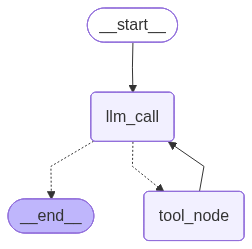

In [8]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


## Step 8: Invoke the graph

Student note:

The question enters the graph as a `HumanMessage`.

The graph keeps running until the LLM no longer asks for a tool.


In [9]:
from langchain_core.messages import HumanMessage


messages = [
    HumanMessage(
        content="What is 12 multiplied by 8, then add 10, then divide by 2?"
    )
]

result = agent.invoke(
    {
        "messages": messages,
        "llm_calls": 0
    }
)

for m in result["messages"]:
    m.pretty_print()


================================ Human Message =================================

What is 12 multiplied by 8, then add 10, then divide by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (call_y9zVSqjbIQEIJyEdtCm9ok6u)
 Call ID: call_y9zVSqjbIQEIJyEdtCm9ok6u
  Args:
    a: 12
    b: 8
  add (call_qIvD7m4hh6Bq5tpKUAkI2C0T)
 Call ID: call_qIvD7m4hh6Bq5tpKUAkI2C0T
  Args:
    a: 96
    b: 10
  divide (call_uawbmsdEHjtwcWUi61XLsLEE)
 Call ID: call_uawbmsdEHjtwcWUi61XLsLEE
  Args:
    a: 106
    b: 2
================================= Tool Message =================================

96
================================= Tool Message =================================

106
================================= Tool Message =================================

53.0
================================== Ai Message ==================================

12 × 8 = 96  
96 + 10 = 106  
106 ÷ 2 = 53  

Answer: **53**


## Step 9: Print only the final answer

In [10]:
print(result["messages"][-1].content)


12 × 8 = 96  
96 + 10 = 106  
106 ÷ 2 = 53  

Answer: **53**


# Student Notes

## What is LangGraph doing here?

LangGraph is controlling the workflow.

It decides:

```text
Should the LLM continue?
Should a tool run?
Should the graph stop?
```

## Key idea

LangChain gives tools to the model.

LangGraph controls how the model and tools work together.

## Simple explanation

```text
User asks a question
↓
LLM decides what to do
↓
If tool is needed, tool_node runs the tool
↓
Tool result goes back to LLM
↓
LLM gives final answer
```

## Why this matters

This same pattern can be used for:

- RAG workflows
- multi-step agents
- approval workflows
- customer support bots
- HR policy chatbots
- business automation agents
